In [1]:
pip install pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('../data set/business_dev_leads_cleaned.csv')

In [5]:
df.head()

,Lead_ID,Lead_Source,Lead_Date,Conversion_Status,Conversion_Date,Revenue_Value,Marketing_Cost,Sales_Representative,Region
0,L0001,Social Media,2024-01-13,Not Converted,NaN,0.00,300,Bob Martinez,South
1,L0002,Referral,2024-02-22,Not Converted,NaN,0.00,150,Emma Okafor,North
2,L0003,Direct,2024-08-04,Converted,2024-08-22,6405.02,180,Emma Okafor,Central
3,L0004,Social Media,2024-10-14,Not Converted,NaN,0.00,300,Emma Okafor,West
4,L0005,Referral,2024-08-17,Not Converted,NaN,0.00,150,Alice Chen,South


In [6]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Lead_ID               300 non-null    object 
 1   Lead_Source           300 non-null    object 
 2   Lead_Date             300 non-null    object 
 3   Conversion_Status     300 non-null    object 
 4   Conversion_Date       80 non-null     object 
 5   Revenue_Value         300 non-null    float64
 6   Marketing_Cost        300 non-null    int64  
 7   Sales_Representative  300 non-null    object 
 8   Region                300 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 21.2+ KB
None


In [7]:
print(df.isnull().sum())

Lead_ID                   0
Lead_Source               0
Lead_Date                 0
Conversion_Status         0
Conversion_Date         220
Revenue_Value             0
Marketing_Cost            0
Sales_Representative      0
Region                    0
dtype: int64


In [11]:
df.isnull().any()

Lead_ID                 False
Lead_Source             False
Lead_Date               False
Conversion_Status       False
Conversion_Date          True
Revenue_Value           False
Marketing_Cost          False
Sales_Representative    False
Region                  False
dtype: bool

In [10]:
# Conversion_Date is a date column - null values likely mean no conversion yet
# Options: 1) Keep as NaT, 2) Forward fill, or 3) Fill with 'Not Converted'
# Using forward fill as an example:
df['Conversion_Date'].fillna(method='ffill', inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_27208\2873587672.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Conversion_Date'].fillna(method='ffill', inplace=True)


In [12]:
df.isnull().any()

Lead_ID                 False
Lead_Source             False
Lead_Date               False
Conversion_Status       False
Conversion_Date          True
Revenue_Value           False
Marketing_Cost          False
Sales_Representative    False
Region                  False
dtype: bool

In [15]:
df['Lead_Date'] = pd.to_datetime(df['Lead_Date'])
df['Conversion_Date'] = pd.to_datetime(df['Conversion_Date'], errors='coerce')
df['Revenue_Value'] = df['Revenue_Value'].fillna(0)
df.to_csv('cleaned_data.csv', index=False)
print("Cleaned! Rows:", len(df))

Cleaned! Rows: 300


In [16]:
converted = df[df['Conversion_Status'] == 'Converted'].copy()

In [17]:
# KPI 1 - Lead Conversion Rate
lcr = len(converted) / len(df) * 100
print(f"Conversion Rate: {lcr:.1f}%")

Conversion Rate: 26.7%


In [18]:
# KPI 2 - CAC
cac = df['Marketing_Cost'].sum() / len(converted)
print(f"CAC: ${cac:.0f}")

CAC: $818


In [19]:
# KPI 3 - Revenue per Client
rpc = converted['Revenue_Value'].mean()
print(f"Revenue per Client: ${rpc:.0f}")

Revenue per Client: $8378


In [20]:
# KPI 4 - Avg Sales Cycle
converted['Cycle_Days'] = (converted['Conversion_Date'] - converted['Lead_Date']).dt.days
avg_cycle = converted['Cycle_Days'].mean()
print(f"Avg Sales Cycle: {avg_cycle:.0f} days")

# KPI 5 - Monthly Growth Rate
converted['Month'] = converted['Conversion_Date'].dt.to_period('M')
monthly = converted.groupby('Month')['Revenue_Value'].sum()
growth = monthly.pct_change().mean() * 100
print(f"Avg Monthly Growth: {growth:.1f}%")

# KPI 6 - Lead Source Performance
src = df.groupby('Lead_Source').apply(
    lambda x: (x['Conversion_Status']=='Converted').sum() / len(x) * 100
)
print("\nConversion Rate by Source:")
print(src)

Avg Sales Cycle: 45 days
Avg Monthly Growth: 69.8%

Conversion Rate by Source:
Lead_Source
Direct            33.823529
Email Campaign    22.413793
Referral          33.333333
Social Media      15.517241
Website           27.941176
dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_27208\3311668509.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  src = df.groupby('Lead_Source').apply(


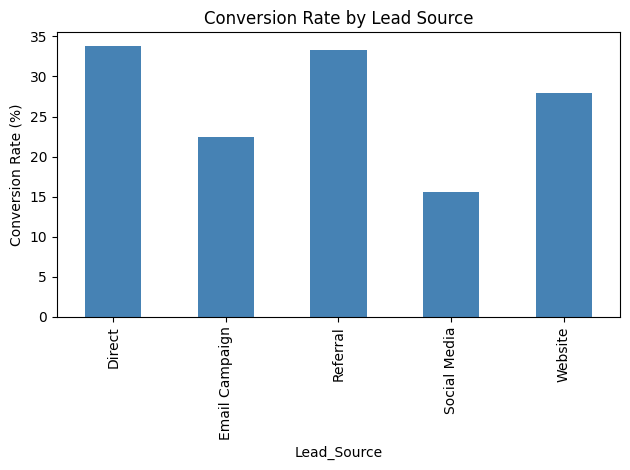

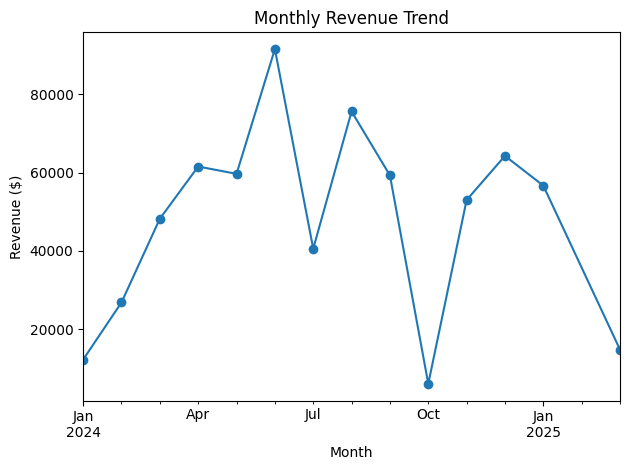

In [21]:
import matplotlib.pyplot as plt

# Chart 1 - Conversion Rate by Source
src.plot(kind='bar', color='steelblue', title='Conversion Rate by Lead Source')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.savefig('chart_conversion_by_source.png')
plt.show()

# Chart 2 - Monthly Revenue
monthly.plot(kind='line', marker='o', title='Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('chart_monthly_revenue.png')
plt.show()

In [22]:
kpi_df = pd.DataFrame({
    'KPI': ['Conversion Rate','CAC','Revenue per Client','Avg Sales Cycle','Monthly Growth'],
    'Value': [f'{lcr:.1f}%', f'${cac:.0f}', f'${rpc:.0f}', f'{avg_cycle:.0f} days', f'{growth:.1f}%'],
    'Benchmark': ['25%','$350','$8,000','30 days','5%']
})
kpi_df.to_excel('KPI_Results.xlsx', index=False)
print("Saved to Excel!")

Saved to Excel!
